# Análise dos Dados do Airbnb - Rio de Janeiro

Podemos considerá-lo como uma plataforma que oferece opções além de hotéis para a hospedagem de clientes. É permitido anunciar um espaço disponível para alugar durante um curto período, como uma casa, ou mesmo um quarto e também podem reservar acomodações em qualquer lugar do mundo.

No final de 2018, a Startup fundada há 10 anos, já havia hospedado mais de <b>300 milhões de pessoas</b> ao redor de todo o mundo, desafiando as redes hoteleiras tradicionais e se tornando uma das <b>maiores do mundo</b>.

Uma das iniciativas do Airbnb é disponibilizar dados do site, para algumas das principais cidades do mundo. Por meio do portal [Inside Airbnb](http://insideairbnb.com/), é possível baixar uma grande quantidade de dados para desenvolver projetos e soluções de Data Science.

Neste notebook iremos analisar os dados referentes à cidade do <b>Rio de Janeiro</b>, e ver quais insights podem ser extraídos a partir de dados brutos.


<div align = "center">
<img src="imagens/copacabana.jpg" width=80%>
</div>

O <b>Rio de Janeiro</b> é a capital do estado homônimo e a segunda maior metrópole do Brasil, sendo mundialmente conhecida por suas belezas naturais, onde o mar se funde com a montanha. A cidade possui uma população de mais de seis milhões de habitantes, sendo um dos <b>principais centros econômicos, culturais e turísticos do país</b>. Diferentemente de outros destinos de negócios, o Rio de Janeiro possui uma forte <b>vocação para o turismo de lazer</b>, atraindo milhões de visitantes anualmente para desfrutar de suas praias famosas, além de eventos globais como o Carnaval e o Réveillon. Como informações de destaque, a cidade abriga marcos icônicos como o Cristo Redentor e o Pão de Açúcar, é o principal polo da indústria petrolífera do Brasil e conta com um vibrante setor de serviços, tornando o local extremamente atrativo e dinâmico.

O <b>objetivo</b> deste projeto, portanto, é fazer uma <b>análise exploratória</b> dos dados fornecidos pelo Inside Airbnb para identificarmos informações relevantes, possíveis padrões, chegando a conclusões que nos elucidem mais a respeito de como é utilizado o aplicativo de hospedagem em uma das cidades mais populares da América do Sul. <b>O desfecho atingido pode contribuir tanto para aqueles que se interessam em visitar o local, quanto para entendermos o impacto da plataforma no mercado local.</b>

## Obtenção dos Dados

Os dados foram obtediso a partir de um csv disponivel no site citado previamente.Para essa análise será baixado o arquivo: listing.csv .

In [34]:
# importar os pacotes necessarios
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno
import numpy as np
import folium

%matplotlib inline
# tamanho dos gráficos
plt.rcParams["figure.figsize"] = [10,5]
# tamanho dos dados
plt.rcParams["font.size"] = 12

In [35]:
# importar o arquivo listings.csv para um DataFrame
df = pd.read_csv("dataset/listings.csv")

## Análise dos Dados

Esta etapa tem por objetivo criar uma consciência situacional inicial e permitir um entendimento de como os dados estão estruturados.

**Dicionário das variáaveis**

* `id` - número de id para identificar o imóvel
* `name` - nome da propriedade
* `host_id` - número de id do proprietário da propriedade
* `neighbourhood_group` - esta coluna estar com valores invalidos
* `neighbourhood` - nome dos distritos
* `latitude` - coordenada da latitude da propriedade
* `longetude` - coordenada de longitude da propriedade
* `room_type` - tipo de quarto
* `price` - preço do aluguel do imóvel
* `minimum_nights` - mínima de noites para reserva
* `number_of_reviews` - número de reviews que a propriedade possui
* `last_review` - data do último review
* `reviews_per_month` - quantidade de reviews por mês
* `calculated_host_listings_count` - quantidade de imóveis do mesmo anfitrião
* `availability_365` - número de dias de disponivilidade dentro de 365 dias

## Análise exploratória dos dados

In [36]:
print("Entradas: ", df[df.columns[0]].count())
print("Variáveis: ", df.shape[1])

Entradas:  43068
Variáveis:  18


In [37]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,821198084644106078,Bright and Peaceful Leblon Loft,84350716,Katrina,NaN,Leblon,-22.982818,-43.222457,Entire home/apt,580.0,2,86,2025-09-19,2.72,1,82,40,NaN
1,821198370698658112,Copacabana 100% reformado.,4347269,Patrick,NaN,Copacabana,-22.984090,-43.191770,Entire home/apt,1900.0,5,0,NaN,NaN,2,364,0,NaN
2,821200521820144734,hambiente familia,499903412,Vanessa,NaN,Pavuna,-22.814911,-43.379011,Entire home/apt,700.0,1,0,NaN,NaN,2,365,0,NaN
3,821213014263313420,Amazing en suite bedroom Leblon,449763717,Alvaro,NaN,Leblon,-22.981910,-43.225990,Private room,NaN,2,3,2024-05-02,0.10,2,0,0,NaN
4,821223043903573522,Incrível apartamento frente mar,25961210,Katia,NaN,Barra da Tijuca,-23.010000,-43.344820,Entire home/apt,500.0,2,11,2025-08-26,0.60,1,234,10,NaN


Podemos observar a ausência de valores em colunas tais como `neighbourhood_group` e `license`. Também é possivel visualizar uma certeza discrepância em `minimum_nights`. Esses dados serão tratados posteriomente para termos uma análise mais fieis.

In [38]:
# verificar o tipo das variáveis
display(df.dtypes)

id                                  int64
name                               object
host_id                             int64
host_name                          object
neighbourhood_group               float64
neighbourhood                      object
latitude                          float64
longitude                         float64
room_type                          object
price                             float64
minimum_nights                      int64
number_of_reviews                   int64
last_review                        object
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
number_of_reviews_ltm               int64
license                           float64
dtype: object

## Porcentagem de valores ausentes no dataset

A qualidade de um dataset está diretamente relacionada à quantidade de valores ausentes. É importante entender logo no início se esses valores nulos são significativos comparados ao total de entradas.

* É possivel ver que as colunas `license` e `neighbourhood_group` possuem 100% dos seus valores faltantes.
* As variáveis `reviews_per_month` e `last_review` possuem como valores nulos mais da metade das linhas.

In [39]:
# ordenar em ordem decrescente as variáveis por seus valores ausentes
(round((df.isnull().sum()/df.shape[0]),2)*100).sort_values(ascending = False)

license                           100.0
neighbourhood_group               100.0
reviews_per_month                  21.0
last_review                        21.0
price                              10.0
neighbourhood                       0.0
latitude                            0.0
longitude                           0.0
room_type                           0.0
name                                0.0
minimum_nights                      0.0
number_of_reviews                   0.0
host_name                           0.0
host_id                             0.0
calculated_host_listings_count      0.0
availability_365                    0.0
number_of_reviews_ltm               0.0
id                                  0.0
dtype: float64

In [40]:
# verificar quantidade de itens por culuna
df.count().sort_values(ascending = False)

id                                43068
calculated_host_listings_count    43068
host_id                           43068
number_of_reviews_ltm             43068
neighbourhood                     43068
latitude                          43068
longitude                         43068
room_type                         43068
name                              43068
minimum_nights                    43068
number_of_reviews                 43068
availability_365                  43068
host_name                         43057
price                             38670
reviews_per_month                 33882
last_review                       33882
neighbourhood_group                   0
license                               0
dtype: int64

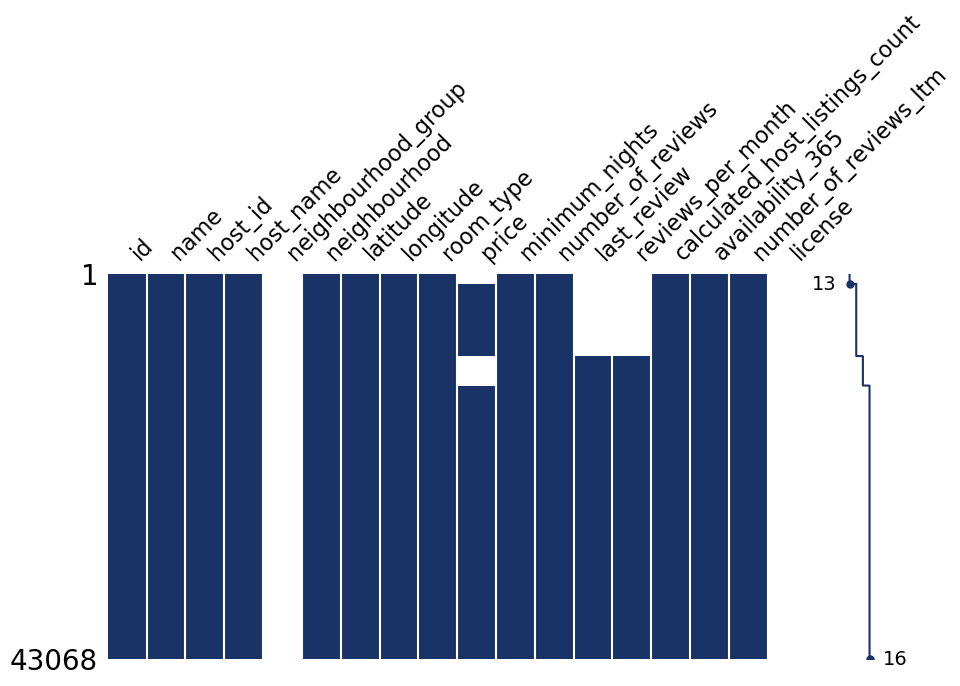

In [41]:
# gráfico de valores ausentes
missingno.matrix(df, figsize = (10,5),  color=(0.1, 0.2, 0.4), sort="ascending");
plt.show()

### Limpeza De Dados Ausentes

Sem nenhuma perda de dados, podemos excluir as colunas `neighbourhood_group` e `license`, pois não apresentam informações.

In [42]:
# criar uma cópia do dataframe original
df_hk = df.copy()

# excluir colunas com dados faltantes
df_hk.drop(columns=['neighbourhood_group', 'license'], inplace=True)

A coluna `reviews_per_month`, como se trata de uma variável quantitativa, irei preencher os valores ausentes com a mediana.

In [43]:
med_review = df_hk['reviews_per_month'].median()
print('Mediana de avaliações por mês:', med_review)

Mediana de avaliações por mês: 0.74


In [44]:
med_price = df_hk["price"].median()
print('Mediana de preço:', med_price)

Mediana de preço: 317.0


In [45]:
df_hk = df_hk.fillna({'price': med_price})

In [46]:
# preencher as informações faltantes com a mediana
df_hk = df_hk.fillna({'reviews_per_month': med_review})

A coluna `last_review` será deletada, pois sua inexistência não afetará.

In [47]:
# excluir coluna com dados faltantes
df_hk.drop(columns=['last_review'], inplace=True)

Verificaremos os resultados obtidos após a limpeza.

In [48]:
# verificar dados ausentes
(df_hk.isnull().sum()).sort_values(ascending = False)

host_name                         11
id                                 0
name                               0
host_id                            0
neighbourhood                      0
latitude                           0
longitude                          0
room_type                          0
price                              0
minimum_nights                     0
number_of_reviews                  0
reviews_per_month                  0
calculated_host_listings_count     0
availability_365                   0
number_of_reviews_ltm              0
dtype: int64

Podemos observar que apenas a variável `nome`, que representa o nome da propriedade anunciada, possui dados ausente. VEjamos que não podemos excluir essa coluna, pois seria uma perda de dados massiva a respeito de uma única entrada ausente. Seria possível remover a linha em que ela se encontra  para manter o dataset com todos os dados, mas não saber o nome da propriedade, não influi em um problema relevante para análise, haja vista que temos informações significativas sobre o imóvel, como:preço, quantidade de quartos, tipo, etc. Assim, irei optar por manter o dataset com as mesmas informações.

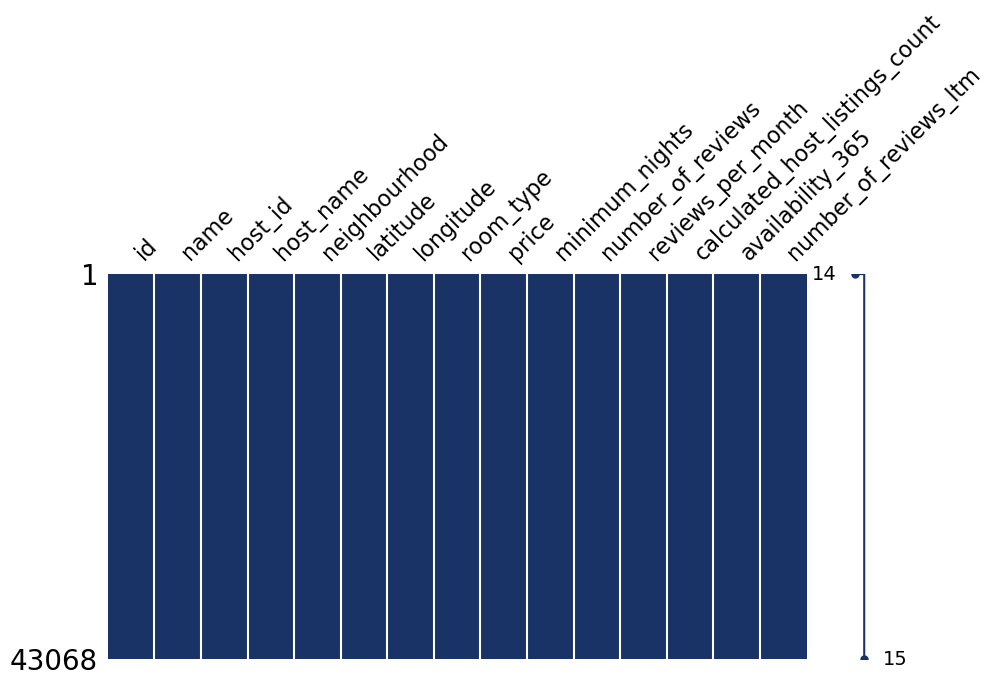

In [49]:
missingno.matrix(df_hk, figsize = (10,5),  color=(0.1, 0.2, 0.4), sort="ascending");
plt.show()

### Tipo de distribuição de variável

Para identificar a distrivuição das variáveis, irei plotar o histograma das variáveis numéricas do dataset, bem como um gráfico hexa binário que relaciona latitude e longitude com o preço.

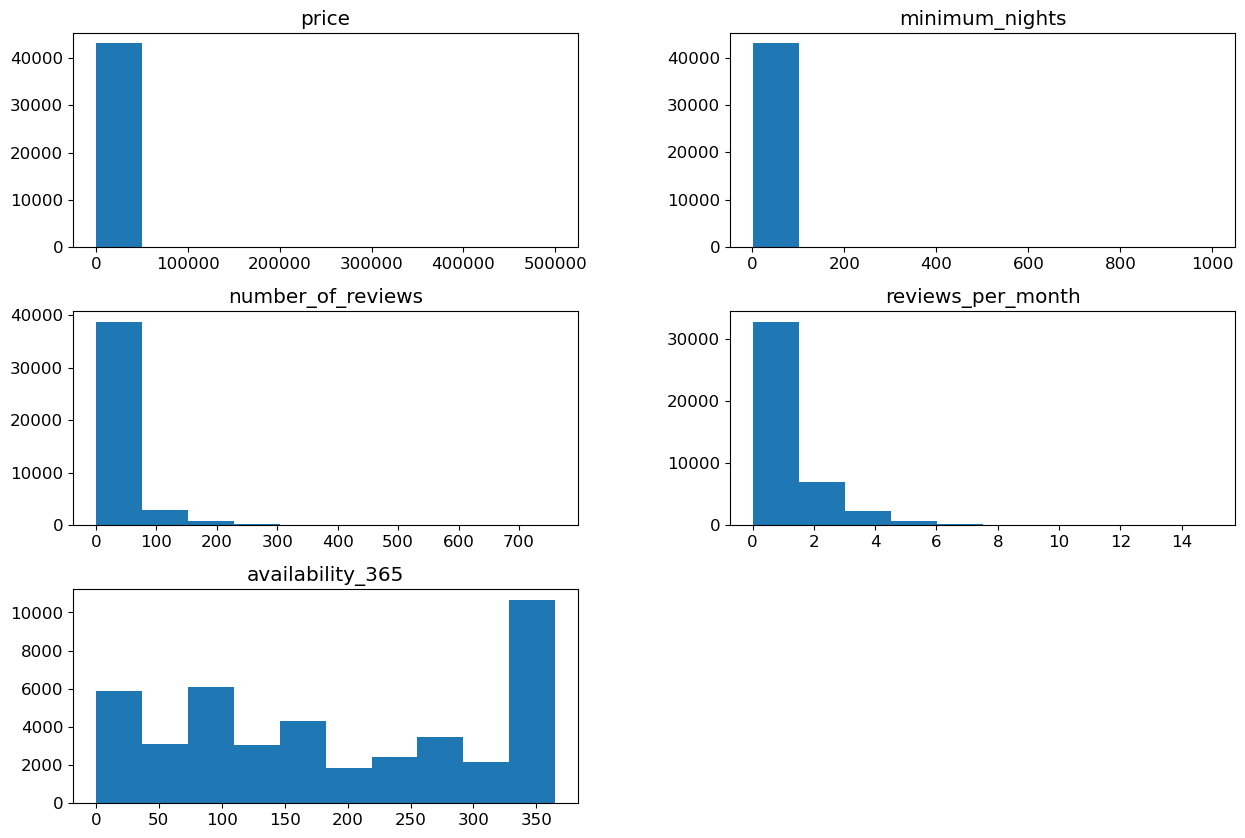

In [50]:
# plotar o histograma das variáveis numéricas
df_hk[['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'availability_365']].hist(figsize=(15,10), grid=False);
plt.show()

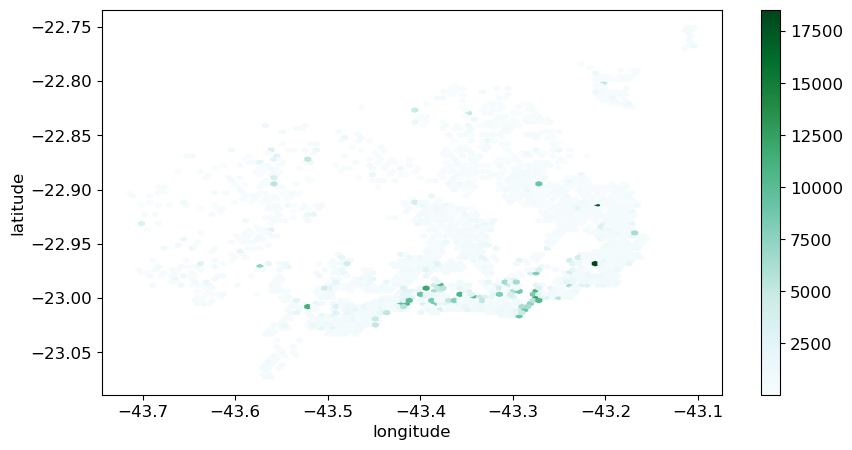

In [51]:
# plotar gráfico hexabinário
df_hk.plot.hexbin(x = 'longitude', y='latitude', C='price', figsize=(10,5));
plt.show()

Apenas pela visualização dos gráficos é possível verificar uma forte discrepância em algumas variáveis como `price` e `minimum_nights`,o que pode ser um forte indicativo da presença de um <b>outlier</b>. Iremos examinar mais a fundo a informação.

## Limpando outliers

Outliers é um dado que se difere significativamente das observações. Para tratar dos outliers desse conjunto de dados, iremos analisar a distribuição estatística, plotar boxplots e calcular os limites utilizando a regra do IQR Score.

Sendo o IQR a subtração do Terceiro Quatil (75%) pelo Primeiro Quartil (25%)

### IQR = Q3 - Q1

vamos verificar o resumo estatístico das variáveis.

In [52]:
# ver o resumo estatístico das variáveis numéricas
df_hk[['price', 'minimum_nights', 'number_of_reviews', 
       'reviews_per_month', 'availability_365']].describe().round(1)

,price,minimum_nights,number_of_reviews,reviews_per_month,availability_365
count,43068.0,43068.0,43068.0,43068.0,43068.0
mean,676.6,3.7,26.2,1.1,191.4
std,4159.8,15.4,48.6,1.2,126.1
min,30.0,1.0,0.0,0.0,0.0
25%,214.0,1.0,1.0,0.3,85.0
50%,317.0,2.0,7.0,0.7,177.0
75%,516.0,3.0,30.0,1.4,327.0
max,500000.0,1000.0,760.0,15.0,365.0


A partir dessas informações, podemos perceber características importantes, por exemplo:

* A variável `price` tem o mínimo de 30.
* Lembrando que a variável `price` trata do preço de diária dos imóveis em moeda local (BRL), estamos vendo que o Q3 está em 516 Reais, mas o máximo está em 500 mil Reais. Claramente, há outliers por aqui.
* A variável `minimum_nights` tem como seu máximo o valor 1000, sendo que o Q3 esta1 em 3. Claramente , temos outliers nessa variável.
* As variáveis `number_of_reviews` , `reviews_per_month` e `availability_365` também podem conter outliers, mas não vamos nos preocupar com elas agora.

Seguiremos os passos a seguir:

* Definir o Q1 e Q3 para as variáveis que serão limpas.
* Calcular o IQR para as variáveis.
* Definir o limite superior e inferior para cortar os outliers.
* Remover os outliers.

### Variável `price`

In [53]:
# identificar o iqr da variável price
q1_price = df_hk.price.quantile(.25)
q3_price = df_hk.price.quantile(.75)
IQR_price = q3_price - q1_price
print('IQR da variável price: ', IQR_price)

# definir os limites superiores e inferiores                                      
sup_price = q3_price + 1.5 * IQR_price
inf_price = q1_price - 1.5 * IQR_price

print('Limite superior de price: ', sup_price)
print('Limite inferior de price: ', inf_price)

IQR da variável price:  302.0
Limite superior de price:  969.0
Limite inferior de price:  -239.0


Aqui podemos ver que, apesar de não termos outliers na parte inferior,ainde sim precisam ser tratados.

Vamos plotar um bloxplot para visualizar a diferença feita pela limpeza.

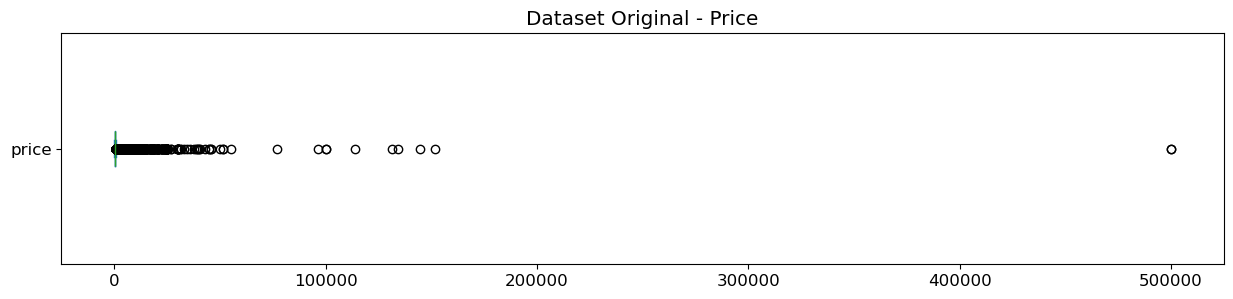

O dataset possui 43068 colunas
2768 Entradas acima de 1447.0
Representam 6.43% do dataset


In [54]:
# verificar o conjunto de dados original
fig, ax = plt.subplots(figsize=(15,3))
df_hk.price.plot(kind='box', vert=False);
ax.set_title('Dataset Original - Price')
plt.show()

print("O dataset possui {} colunas".format(df_hk.shape[0]))
print("{} Entradas acima de 1447.0".format(len(df_hk[df_hk.price > 1447.0])))
print("Representam {:.2f}% do dataset".format((len(df_hk[df_hk.price > 1447.0]) / df_hk.shape[0])*100))

In [55]:
# copiar o dataset
df_clean = df_hk.copy()
# excluir valores acima do limite superior
df_clean.drop(df_clean[df_clean.price > 1447.0].index, axis=0, inplace=True)
# excluir valores iguais a 0
df_clean.drop(df_clean[df_clean.price == 0.0].index, axis=0, inplace=True)

print('Shape antes da limpeza: ', df_hk.shape)
print('Shape após a limpeza: ',df_clean.shape)

Shape antes da limpeza:  (43068, 15)
Shape após a limpeza:  (40300, 15)


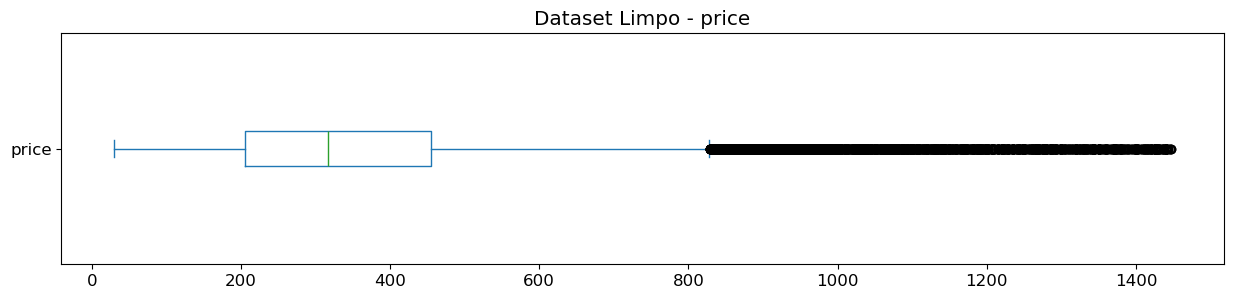

Tamanho original: 43068 colunas
Tamanho atual: 40300 colunas


In [56]:
# verificar o conjunto limpo
fig, ax = plt.subplots(figsize=(15,3))
df_clean.price.plot(kind='box', vert=False);
ax.set_title('Dataset Limpo - price')
plt.show()

print("Tamanho original: {} colunas".format(df_hk.shape[0]))
print("Tamanho atual: {} colunas".format(df_clean.shape[0]))

Apesar do bloxplot mostrar alguns dados como outliers, eles estão sendo calculados em relação ao dataset limpo, que considerou os quartis da base original.

Iremos verificar como se apresentar o histograma e o gráfico hexa binário para a variável após tais modificações.

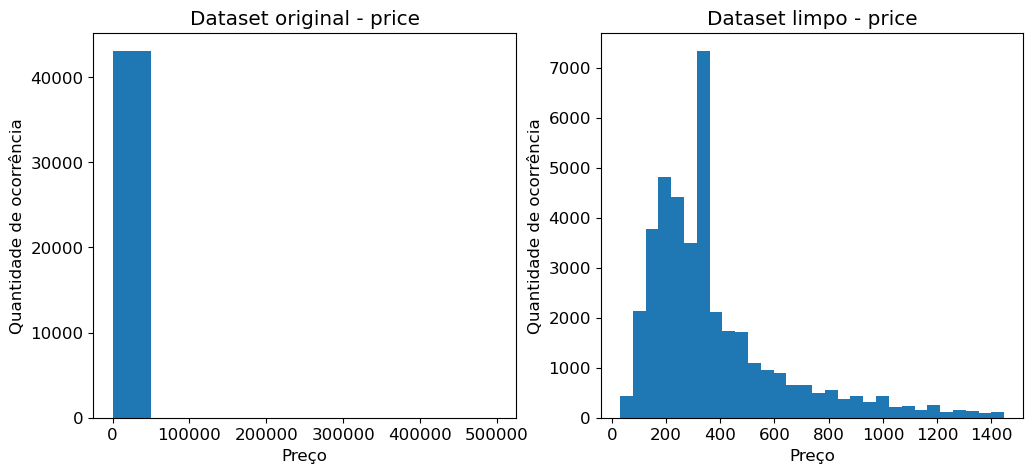

In [57]:
# plotar o histograma da variável price
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (12, 5))

df_hk.price.plot(kind = 'hist', ax = ax1, bins = 10)
ax1.set_title("Dataset original - price")
ax1.set_xlabel("Preço")
ax1.set_ylabel("Quantidade de ocorrência")

df_clean.price.plot(kind='hist', bins=30, ax=ax2)
ax2.set_title("Dataset limpo - price")
ax2.set_xlabel("Preço")
ax2.set_ylabel("Quantidade de ocorrência")

plt.show()

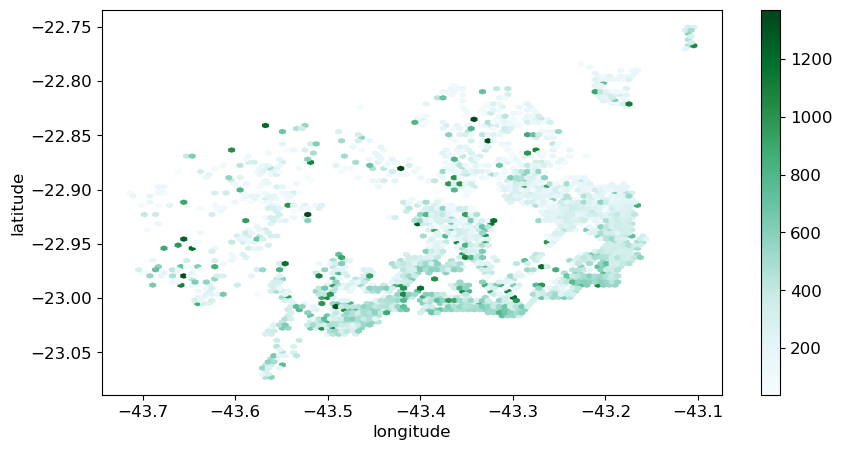

In [58]:
# plotar gráfico hexabinário
df_clean.plot.hexbin(x = 'longitude', y='latitude', C='price', figsize=(10,5));
plt.show()

### Variável `minimum_nights`

In [59]:
# identificar o IQR para a variável minimum_nights
q1_minimum_nights = df_hk.minimum_nights.quantile(.25)
q3_minimum_nights = df_hk.minimum_nights.quantile(.75)
IQR_minimum_nights = q3_minimum_nights - q1_minimum_nights
print('IQR da variável minimum_nights: ', IQR_minimum_nights)

# definindo os limites                                       
sup_minimum_nights = q3_minimum_nights + 1.5 * IQR_minimum_nights
inf_minimum_nights = q1_minimum_nights - 1.5 * IQR_minimum_nights

print('Limite superior de minimum_nights: ', sup_minimum_nights)
print('Limite inferior de minimum_nights: ', inf_minimum_nights)

IQR da variável minimum_nights:  2.0
Limite superior de minimum_nights:  6.0
Limite inferior de minimum_nights:  -2.0


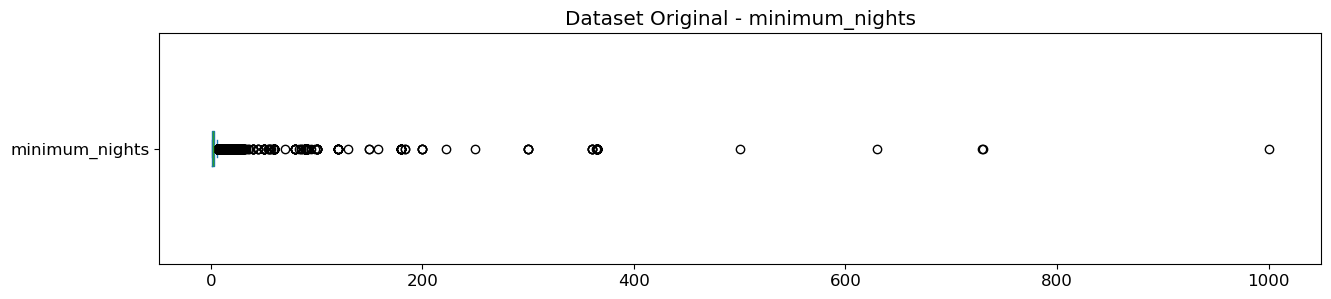

O dataset possui 43068 colunas
191 Entradas acima de 71.0
Representam 0.44% do dataset


In [60]:
# verificar o conjunto original
fig, ax = plt.subplots(figsize=(15,3))
df_hk.minimum_nights.plot(kind='box', vert=False);
ax.set_title('Dataset Original - minimum_nights')
plt.show()

print("O dataset possui {} colunas".format(df_hk.shape[0]))
print("{} Entradas acima de 71.0".format(len(df_hk[df_hk.minimum_nights > 71.0])))
print("Representam {:.2f}% do dataset".format((len(df_hk[df_hk.minimum_nights > 71.0]) / df_hk.shape[0])*100))

In [61]:
# limpar o dataset acima do limite superior
df_clean.drop(df_clean[df_clean.minimum_nights > 71.0].index, axis=0, inplace=True)

print('Shape antes da limpeza: ', df_hk.shape)
print('Shape após a limpeza: ',df_clean.shape)

Shape antes da limpeza:  (43068, 15)
Shape após a limpeza:  (40135, 15)


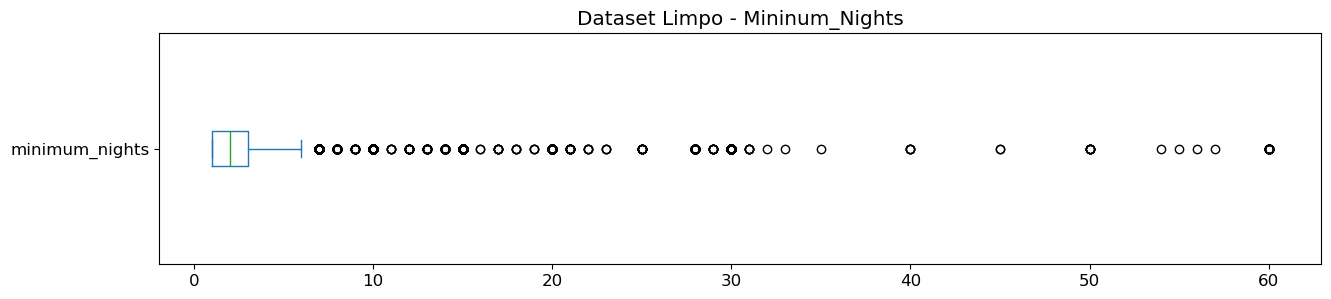

Tamanho original: 43068 colunas
Tamanho atual: 40135 colunas


In [62]:
# verificar o conjunto limpo
fig, ax = plt.subplots(figsize=(15,3))
df_clean.minimum_nights.plot(kind='box', vert=False);
ax.set_title('Dataset Limpo - Mininum_Nights')
plt.show()

print("Tamanho original: {} colunas".format(df_hk.shape[0]))
print("Tamanho atual: {} colunas".format(df_clean.shape[0]))

Vamos verificar a diferença em relação aos histogramas.

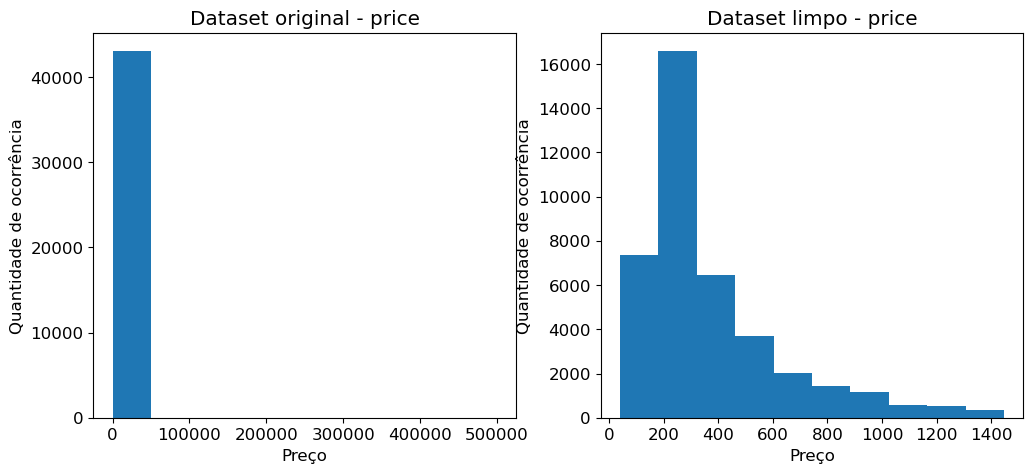

In [63]:
# plotar o histograma da variável price
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (12, 5))

df_hk.price.plot(kind = 'hist', ax = ax1, bins = 10)
ax1.set_title("Dataset original - price")
ax1.set_xlabel("Preço")
ax1.set_ylabel("Quantidade de ocorrência")


df_clean.price.plot(kind = 'hist', ax = ax2)
ax2.set_title("Dataset limpo - price")
ax2.set_xlabel("Preço")
ax2.set_ylabel("Quantidade de ocorrência")

plt.show()

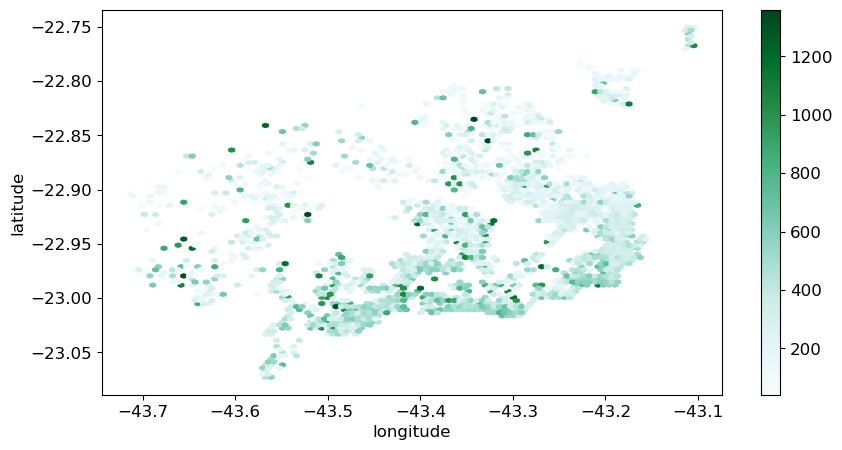

In [64]:
# plotar gráfico hexabinário
df_clean.plot.hexbin(x = 'longitude', y='latitude', C='price', figsize=(10,5));
plt.show()

In [65]:
# identificar o IQR para a variável minimum_nights
q1_minimum_nights = df_hk.minimum_nights.quantile(.25)
q3_minimum_nights = df_hk.minimum_nights.quantile(.75)
IQR_minimum_nights = q3_minimum_nights - q1_minimum_nights
print('IQR da variável minimum_nights: ', IQR_minimum_nights)

# definindo os limites                                       
sup_minimum_nights = q3_minimum_nights + 1.5 * IQR_minimum_nights
inf_minimum_nights = q1_minimum_nights - 1.5 * IQR_minimum_nights

print('Limite superior de minimum_nights: ', sup_minimum_nights)
print('Limite inferior de minimum_nights: ', inf_minimum_nights)


IQR da variável minimum_nights:  2.0
Limite superior de minimum_nights:  6.0
Limite inferior de minimum_nights:  -2.0


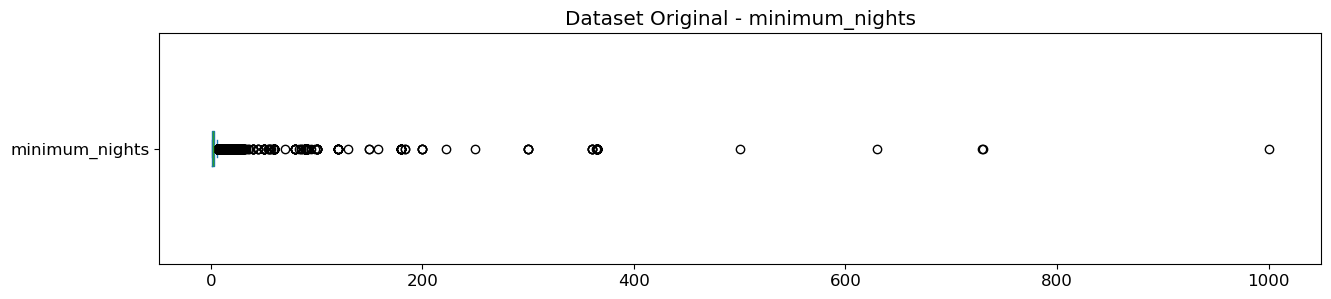

O dataset possui 43068 colunas
191 Entradas acima de 71.0
Representam 0.44% do dataset


In [66]:
# verificar o conjunto original
fig, ax = plt.subplots(figsize=(15,3))
df_hk.minimum_nights.plot(kind='box', vert=False);
ax.set_title('Dataset Original - minimum_nights')
plt.show()

print("O dataset possui {} colunas".format(df_hk.shape[0]))
print("{} Entradas acima de 71.0".format(len(df_hk[df_hk.minimum_nights > 71.0])))
print("Representam {:.2f}% do dataset".format((len(df_hk[df_hk.minimum_nights > 71.0]) / df_hk.shape[0])*100))

In [67]:
# limpar o dataset acima do limite superior
df_clean.drop(df_clean[df_clean.minimum_nights > 71.0].index, axis=0, inplace=True)

print('Shape antes da limpeza: ', df_hk.shape)
print('Shape após a limpeza: ',df_clean.shape)

Shape antes da limpeza:  (43068, 15)
Shape após a limpeza:  (40135, 15)


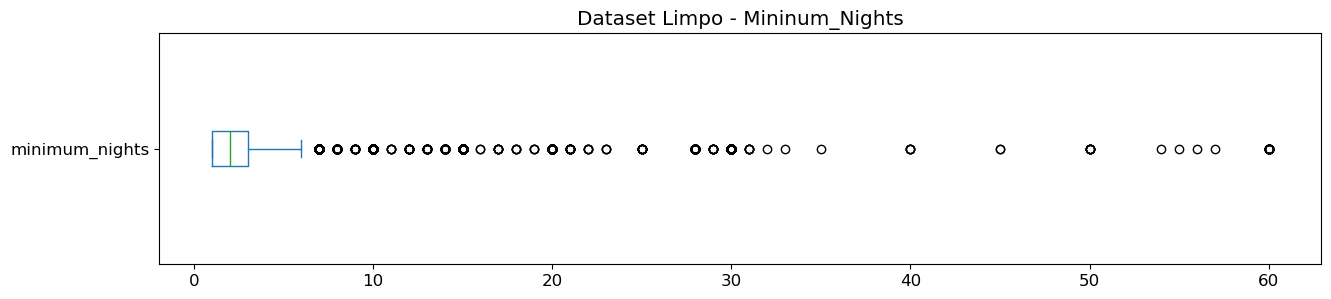

Tamanho original: 43068 colunas
Tamanho atual: 40135 colunas


In [68]:
# verificar o conjunto limpo
fig, ax = plt.subplots(figsize=(15,3))
df_clean.minimum_nights.plot(kind='box', vert=False);
ax.set_title('Dataset Limpo - Mininum_Nights')
plt.show()

print("Tamanho original: {} colunas".format(df_hk.shape[0]))
print("Tamanho atual: {} colunas".format(df_clean.shape[0]))

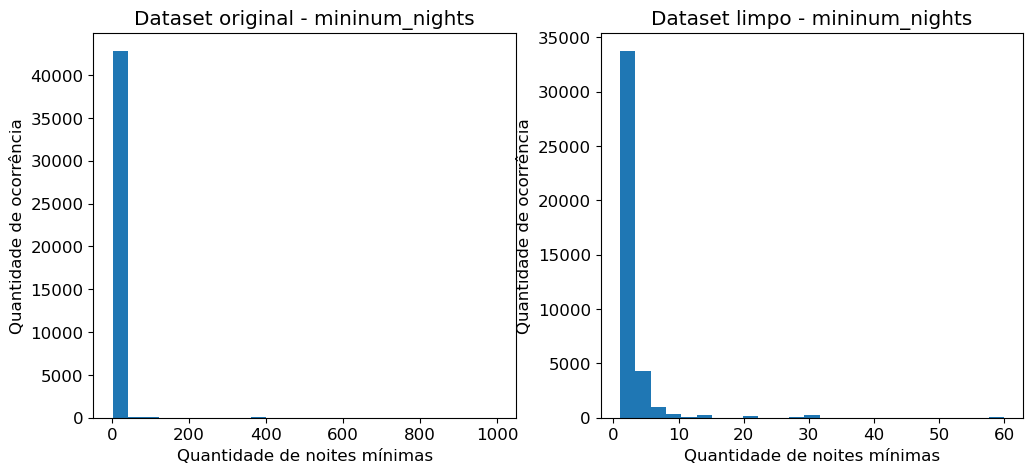

In [69]:
# histograma anterior para minimum_nights
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
df_hk.minimum_nights.plot(kind = 'hist', ax = ax1, bins = 25)
ax1.set_title("Dataset original - mininum_nights")
ax1.set_xlabel("Quantidade de noites mínimas")
ax1.set_ylabel("Quantidade de ocorrência")

# histograma do dataset limpo para minimum_nights
df_clean.minimum_nights.plot(kind = 'hist', ax = ax2, bins = 25)
ax2.set_title("Dataset limpo - mininum_nights")
ax2.set_xlabel("Quantidade de noites mínimas")
ax2.set_ylabel("Quantidade de ocorrência")

plt.show()

### Média de preços por aluguel

In [72]:
# ver a média da coluna `price`
mean_price = (f'{df_clean.price.mean():.2f}')
usd_price = (f'{df_clean.price.mean() / 5.20:.2f}')
print(f'A média de preços é {mean_price} Reais')
print(f'No momento atual, isso representa {usd_price} dolares')

A média de preços é 377.32 Reais
No momento atual, isso representa 72.56 dolares


In [73]:
# média de preços por distrito
df_clean.groupby(['neighbourhood']).price.mean().sort_values(ascending = False)

neighbourhood
Zumbi                   820.000000
Jacaré                  641.333333
Leblon                  549.182042
Lagoa                   524.617391
Ipanema                 521.686618
                           ...    
Gericinó                101.000000
Cidade Universitária     94.333333
Engenho da Rainha        86.500000
Maria da Graça           81.666667
Colégio                  67.000000
Name: price, Length: 152, dtype: float64

In [74]:
# quantidade de imóveis por distrito
df_clean.neighbourhood.value_counts().sort_values(ascending = False)

neighbourhood
Copacabana                  12635
Ipanema                      3258
Barra da Tijuca              3226
Centro                       2212
Recreio dos Bandeirantes     1984
                            ...  
Complexo do Alemão              2
Anchieta                        1
Gericinó                        1
Caju                            1
Colégio                         1
Name: count, Length: 152, dtype: int64

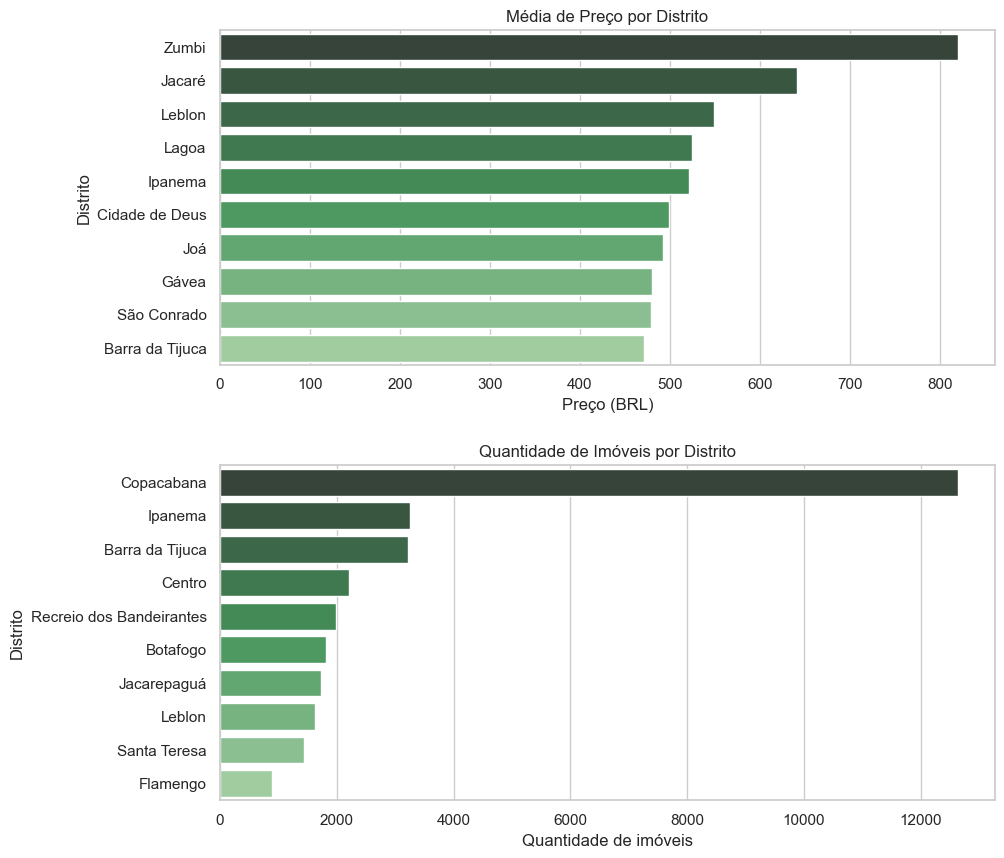

In [76]:
# estilo dos gráficos
sns.set(style="whitegrid")

# calcular métricas apenas uma vez
price_mean = df_clean.groupby("neighbourhood")["price"].mean().sort_values(ascending=False)
count_neigh = df_clean["neighbourhood"].value_counts()

# criar figura
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10,10))
plt.subplots_adjust(hspace=0.3)

# paleta de cores
palette = sns.color_palette("Greens_d", 10)

#média de preço
price_mean_top10 = price_mean.head(10)
sns.barplot(
    x=price_mean_top10.values,
    y=price_mean_top10.index,
    hue=price_mean_top10.index,
    palette=palette[::-1],
    legend=False,
    ax=ax1
)

ax1.set_xlabel("Preço (BRL)")
ax1.set_ylabel("Distrito")
ax1.set_title("Média de Preço por Distrito")

#quantidade de imóveis
count_neigh_top10 = count_neigh.head(10)

sns.barplot(
    x=count_neigh_top10.values,
    y=count_neigh_top10.index,
    hue=count_neigh_top10.index,
    palette=palette[::-1],
    legend=False,
    ax=ax2
)

ax2.set_xlabel("Quantidade de imóveis")
ax2.set_ylabel("Distrito")
ax2.set_title("Quantidade de Imóveis por Distrito")

plt.show()

### Bairros mais caros

In [67]:
# verificar mediana da quantidade de imóveis
qtd_imoveis = df_clean.neighbourhood.value_counts().values
mediana = np.median(qtd_imoveis)
print("A mediana da quantidade de imóveis é", mediana)

A mediana da quantidade de imóveis é 18.0


In [77]:
# verificar os três bairros mais caros com quantidade de imóveis maior ou igual a mediana
df_new = pd.concat([df_clean.neighbourhood.value_counts().rename('Quantidade de imóveis'),
           df_clean.groupby(['neighbourhood']).price.mean().sort_values(ascending = False).rename('Média de preço')], axis = 1).sort_values(by = 'Média de preço', ascending = False)
df_new.loc[df_new['Quantidade de imóveis'] >= 76.0][:3]

,Quantidade de imóveis,Média de preço
neighbourhood,,
Leblon,1626,549.182042
Lagoa,230,524.617391
Ipanema,3258,521.686618


### Preço mínimo e máximo por bairro

In [80]:
# ver preços mínimos por bairros
df_clean.groupby(['neighbourhood']).price.min().sort_values(ascending = False)

neighbourhood
Caju                   398.0
Zumbi                  317.0
Cocotá                 255.0
Anchieta               233.0
Honório Gurgel         230.0
                       ...  
Senador Vasconcelos     43.0
Guaratiba               43.0
Praça Seca              42.0
Campo Grande            41.0
Bonsucesso              40.0
Name: price, Length: 152, dtype: float64

In [81]:
# preços máximos por distrito
df_clean.groupby(['neighbourhood']).price.max().sort_values(ascending = False)

neighbourhood
Jacarepaguá                 1447.0
Copacabana                  1447.0
Ipanema                     1445.0
Recreio dos Bandeirantes    1443.0
Botafogo                    1442.0
                             ...  
Vila Militar                 138.0
Gericinó                     101.0
Maria da Graça                98.0
Cidade Universitária          96.0
Colégio                       67.0
Name: price, Length: 152, dtype: float64

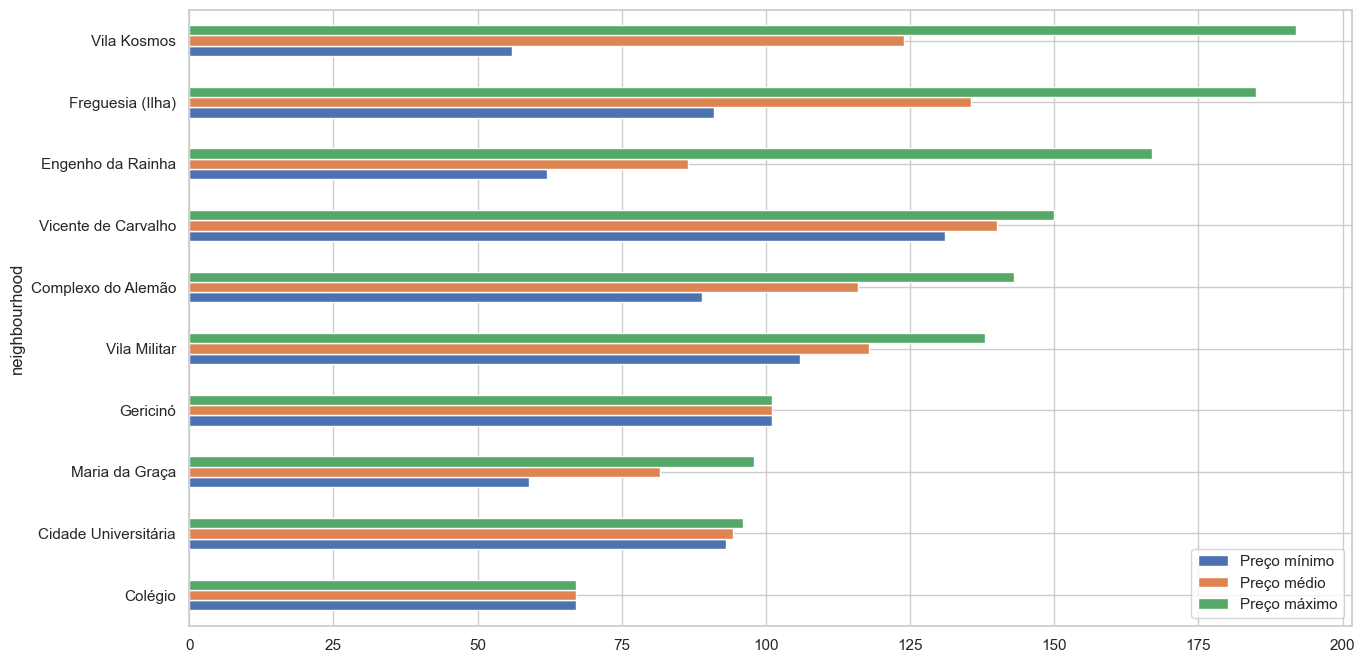

In [82]:
df_price = pd.concat([
    df_clean.groupby(['neighbourhood']).price.min().rename('Preço mínimo'),
    df_clean.groupby(['neighbourhood']).price.mean().rename('Preço médio'),
    df_clean.groupby(['neighbourhood']).price.max().rename('Preço máximo')
], axis=1)

df_price.sort_values('Preço máximo').head(10).plot.barh(figsize=(15, 8))

plt.show()

In [83]:
min_price = (f'{df_clean.price.min():.2f}')
max_price = (f'{df_clean.price.max():.2f}')
brl_price = [f'{df_clean.price.min() / 5.20:.2f}', f'{df_clean.price.max() / 5.20:.2f}']

print(f'O menor preço observado é {min_price} reais')
print(f'No momento atual, isso representa {brl_price[0]} dolar')
print(f'O maior preço observado é {max_price} reais')
print(f'No momento atual, isso representa {brl_price[1]} dolar')

O menor preço observado é 40.00 reais
No momento atual, isso representa 7.69 dolar
O maior preço observado é 1447.00 reais
No momento atual, isso representa 278.27 dolar


### Média de quantidade mínima de noites

In [84]:
# ver a média da coluna `minimum_nights`
mean_minimum_nights = (f'{df_clean.minimum_nights.mean():.2f}')

print(f'O mínimo de noites é {df_clean.minimum_nights.min()}.')
print(f'A média de noites são {mean_minimum_nights}.')
print(f'O máximo de noites são {df_clean.minimum_nights.max()}.')

O mínimo de noites é 1.
A média de noites são 2.80.
O máximo de noites são 60.


In [85]:
# ver a média de noites mínimas por distrito
df_clean.groupby(['neighbourhood']).minimum_nights.mean().sort_values(ascending = False)

neighbourhood
Maracanã                5.496000
Riachuelo               4.842105
Guadalupe               4.750000
Praia da Bandeira       4.666667
Ramos                   4.555556
                          ...   
Anchieta                1.000000
Manguinhos              1.000000
Mangueira               1.000000
Honório Gurgel          1.000000
Cidade Universitária    1.000000
Name: minimum_nights, Length: 152, dtype: float64

### Correlação existente entre as variáveis

O coeficiente de correlação mede a relação estatística entre duas variáveis, sendo que a medida que o valor de uma variável aumente, maior a sua associação. Iremos agora plotar uma matriz de correlação para os valores númericos do nosso datset, onde seguiremos os seguintes passos:

* Cria uma matriz de correlação
* Exibir seu resultado
* Plotar um gráfico de correlação

In [86]:
# criar uma matriz de correlação
corr_df = df_clean[['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'availability_365']].corr(method='pearson');

# mostrar a matriz de correlação
display(corr_df);

,price,minimum_nights,number_of_reviews,reviews_per_month,availability_365
price,1.000000,0.098836,-0.090920,-0.153553,0.088628
minimum_nights,0.098836,1.000000,-0.043556,-0.121567,-0.034469
number_of_reviews,-0.090920,-0.043556,1.000000,0.486973,-0.103140
reviews_per_month,-0.153553,-0.121567,0.486973,1.000000,-0.080010
availability_365,0.088628,-0.034469,-0.103140,-0.080010,1.000000


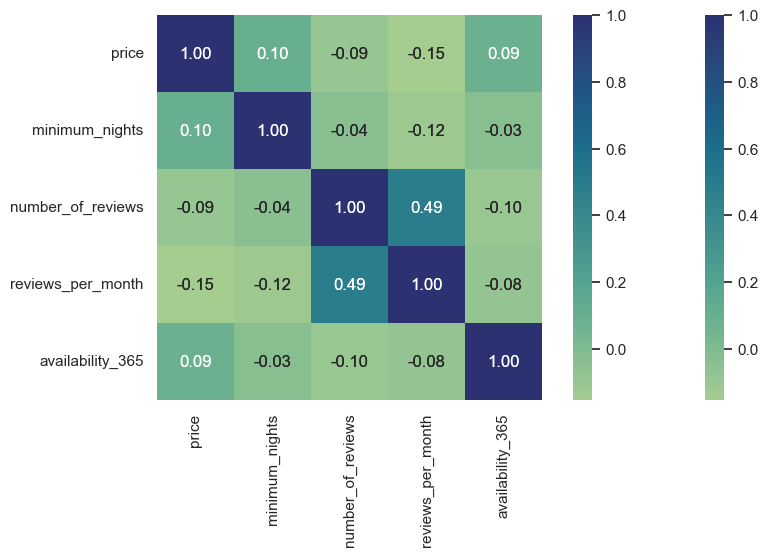

In [88]:
# plotar o gráfico de correlação
sns.heatmap(corr_df,cmap = 'crest', fmt='.2f',square = True, linecolor = 'white', annot = True);
plt.show()

### Tipos de imóveis mais alugados

In [86]:
# mostrar a quantidade de cada tipo de imóvel disponível
df_clean.room_type.value_counts().sort_values(ascending = False)

room_type
Entire home/apt    31709
Private room        7979
Shared room          426
Hotel room            21
Name: count, dtype: int64

In [87]:
# mostrar a porcentagem de cada tipo de imóvel disponível
df_clean.room_type.value_counts()/df_clean.shape[0] * 100

room_type
Entire home/apt    79.005855
Private room       19.880404
Shared room         1.061418
Hotel room          0.052323
Name: count, dtype: float64

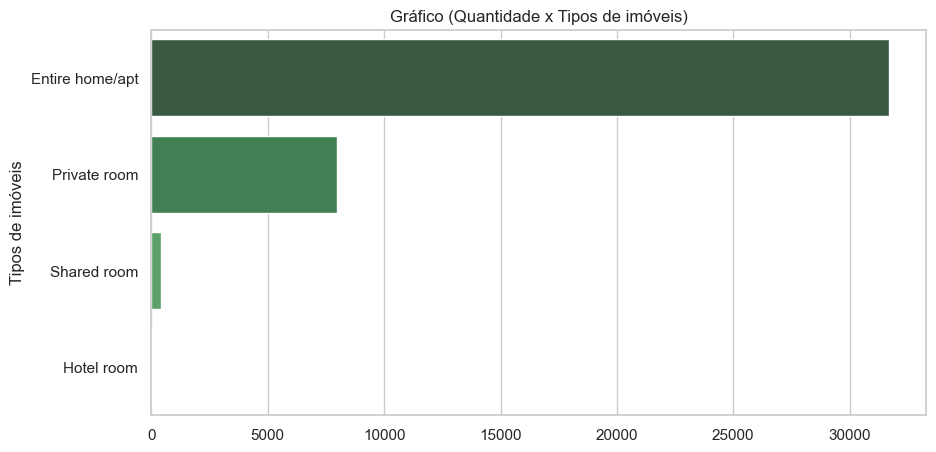

In [88]:
# Plotando gráficos para tipos de imóveis
fig, ax = plt.subplots()

# definir informações iniciais referentes à coloração
sns.set(style="whitegrid", color_codes=True)
data = df_clean.groupby("room_type").size() 
pal = sns.color_palette("Greens_d", len(data))
rank = data.argsort().argsort() 

# gráfico da quantidade de imóveis por seu tipo
ax2 = sns.barplot(
    x=df_clean.room_type.value_counts().values,
    y=df_clean.room_type.value_counts().index,
    hue=df_clean.room_type.value_counts().index,
    palette=list(pal[::-1]),
    legend=False,
    ax=ax
)
ax2.set_ylabel('Tipos de imóveis')
ax2.set_title("Gráfico (Quantidade x Tipos de imóveis)");

plt.show()

### Conclusões

Com base na análise explicitada previamente, constatamos a presença de <b>dados ausentes e outliers</b>, o que nos indica que mesmo uma base relativamente pequena demanda o processo de analisar a qualidade de dados para <b>aprovar/rejeitar</b> as sugestões propostas pelo sistema, bem como necessidade de alteração para obter um dataset mais fidedigno à realidade.

Também observamos que os habitantes do Rio de Janeiro indicam-nos um padrão interessante em relação às escolhas do AirBnb, pois mais de <b> 50% dos usuários</b> analisados ofertam para alugar <b>apartamentos completos</b> e não apenas quartos privados, enquanto <b>somente 1% oferta hotéis</b>. O número mínimo de noites alugadas observado foi um , enquanto sua média varia em aproximadamente 3 dias. Ademais, o menor preço observado foi 40 Reais no bairro do Bonsucessom, cujo é um dos menores em relação a densidade populacional. Já o maior preço obsercado foi 1447 Reais no bairro Jacarepaguá, que de maneira inversamento proporcional, possui a terceira mairo densidade populacional do Rio de Janeiro.

Por fim, lembramos que a base de dados utilizada nessa análise é uma <b>versão resumida</b>, ideal para o que foi proposto nesse projeto de uma abordagem inicial de estudo. Para um estudo mais aprofundado é recomendado que seja utilizado a versão completa.